### Importing necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize

### Reading images from different folders

In [2]:
flowers=glob.glob('ecommerce products/flowers/*.jpg')
butterfly=glob.glob('ecommerce products/Butterfly/Image_*.jpg')
tshirt=glob.glob('ecommerce products/tshirt/*.jpg')
tv=glob.glob('ecommerce products/tv/*.jpg')

In [3]:
print(len(flowers))
print(len(butterfly))
print(len(tshirt))
print(len(tv))

199
199
199
199


In [4]:
plt.imread(flowers[1])

array([[[245, 244, 240],
        [245, 245, 243],
        [251, 251, 249],
        ...,
        [245, 247, 242],
        [223, 223, 221],
        [246, 246, 244]],

       [[251, 250, 246],
        [247, 247, 245],
        [249, 249, 247],
        ...,
        [242, 244, 239],
        [238, 240, 237],
        [240, 242, 239]],

       [[251, 251, 249],
        [248, 248, 246],
        [250, 250, 248],
        ...,
        [230, 232, 227],
        [240, 242, 239],
        [240, 245, 241]],

       ...,

       [[254, 254, 252],
        [251, 251, 249],
        [251, 251, 249],
        ...,
        [252, 252, 250],
        [253, 253, 251],
        [253, 253, 251]],

       [[251, 251, 249],
        [248, 248, 246],
        [248, 248, 246],
        ...,
        [255, 255, 253],
        [248, 248, 246],
        [247, 247, 245]],

       [[250, 250, 248],
        [254, 254, 252],
        [249, 249, 247],
        ...,
        [255, 255, 253],
        [247, 247, 245],
        [253, 252, 248]]

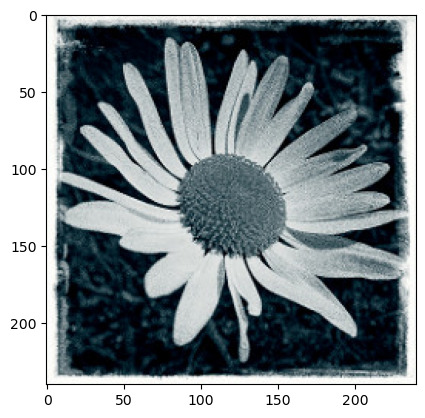

In [5]:
plt.imshow(plt.imread(flowers[1]))

### Reading image and label data and storing it in variables

In [6]:
image=[]
label=[]

for i in flowers:
    img=plt.imread(i)
    image.append(img)
    label.append(0)

for i in butterfly:
    img=plt.imread(i)
    image.append(img)
    label.append(1)

for i in tshirt:
    img=plt.imread(i)
    image.append(img)
    label.append(2)

for i in tv:
    img=plt.imread(i)
    image.append(img)
    label.append(3)

### Storing label value names in dictionary

In [7]:
label_names={0:'flowers',1:'butterfly',2:'tshirt',3:'tv'}

### Plotting some of the figures

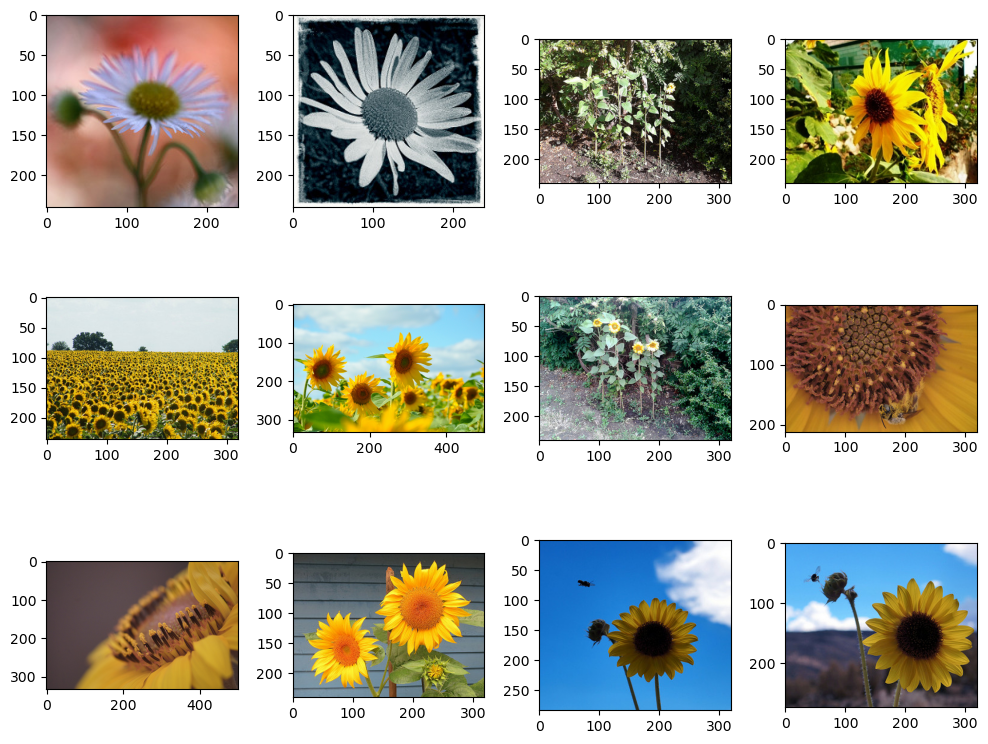

In [8]:
plt.figure(figsize=(10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
plt.tight_layout()

### Shuffling images and labels

In [9]:
image,label=shuffle(image,label)

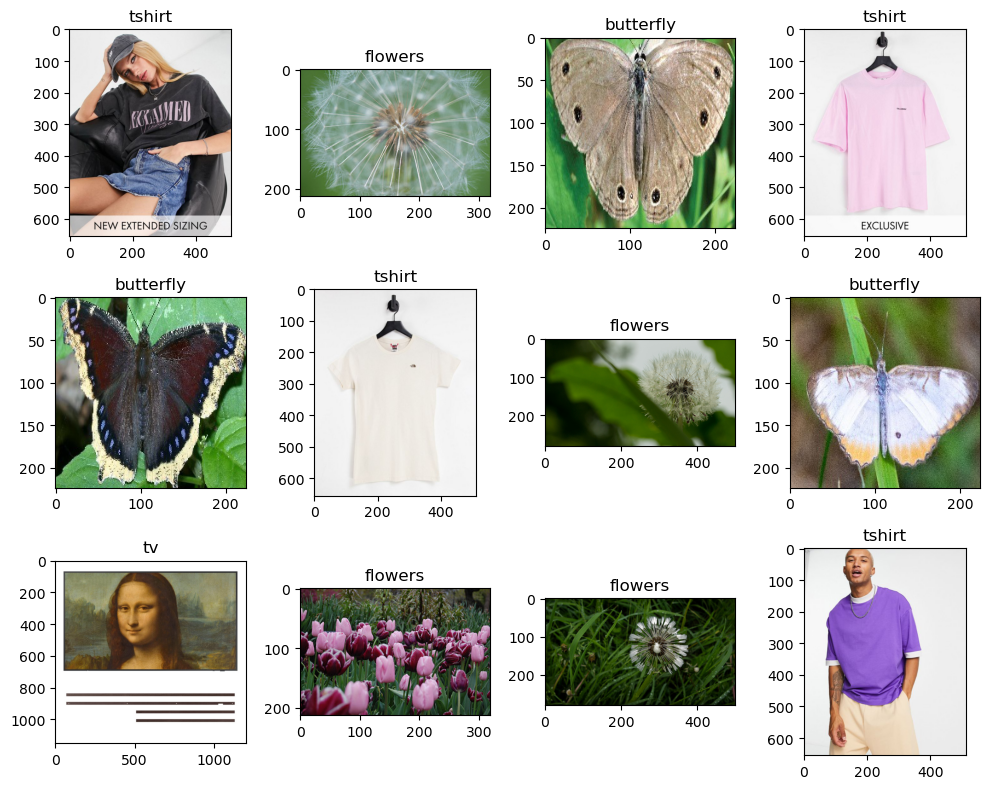

In [10]:
plt.figure(figsize=(10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    plt.title(label_names[label[i]])
plt.tight_layout()

### Checking shape of  some images

In [11]:
for i in range(10):
    print(image[i].shape)

(655, 513, 3)
(213, 320, 3)
(224, 224, 3)
(656, 513, 3)
(224, 224, 3)
(656, 513, 3)
(281, 500, 3)
(224, 224, 3)
(1151, 1200, 3)
(213, 320, 3)


### Resize all images to same height and width

In [12]:
X=[]
for i in image:
    X.append(resize(i,(300,300,3)))

### Converting images and labels to numpy array and storing them as X and y variables

In [13]:
X=np.array(X)
y=np.array(label)

### Reshaping X to 1 dimension

In [14]:
d1,d2,d3,d4=X.shape
X=X.reshape((d1,d2*d3*d4))

### Train Test split

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

### Model creation and training 

In [17]:
model=SVC()

In [18]:
%time model.fit(X_train,y_train)

CPU times: total: 2min 26s
Wall time: 1min 28s


SVC()

### Prediction

In [19]:
%time y_pred=model.predict(X_test)

CPU times: total: 1min 43s
Wall time: 1min 42s


### Evaluation metrics

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
accuracy_score(y_test,y_pred)

0.8375

<Axes: >

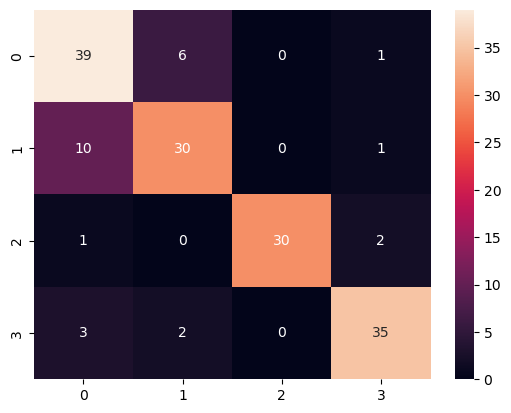

In [22]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        46
           1       0.79      0.73      0.76        41
           2       1.00      0.91      0.95        33
           3       0.90      0.88      0.89        40

    accuracy                           0.84       160
   macro avg       0.86      0.84      0.85       160
weighted avg       0.84      0.84      0.84       160

